# Bloc 3 — Préparation + Modélisation + Optimisation

Phase 1 — Nettoyage final
1. Chargement du df propre
   - Traiter les `inf` (floor_surface)
   - Traiter les NaN (NumberofBuildings, SiteEnergyUse, SecondLargestGFA, ThirdLargestGFA)
   - Traiter les outliers (log1p sur mesures absolues, retrait UW)

Phase 2 — Split
2. Séparer X (features) et y (target)
3. `train_test_split` (test_size=0.2, random_state=42)

Phase 3 — Pipeline
4. Construire un Pipeline scikit-learn :
   - OneHotEncoder (sparse_output=False, handle_unknown='ignore', max_categories=10) sur BuildingType, PrimaryPropertyType, Neighborhood
   - StandardScaler sur les numériques continues
   - Passthrough sur les binaires (use_steam, has_third_use)

Phase 4 — Modélisation
5. Baseline : LinearRegression avec `cross_validate` (scoring : R², neg_MAE)
6. Comparaison : remplacer le modèle dans le pipeline par Ridge, RandomForestRegressor, GradientBoostingRegressor — évaluer chacun avec `cross_validate`
7. Tableau récapitulatif des scores (R² moyen, MAE moyen par modèle)

Phase 5 — Optimisation
8. GridSearchCV sur le meilleur modèle (~100-500 combinaisons) :
   - RandomForest : n_estimators, max_depth, min_samples_split
   - GradientBoosting : n_estimators, max_depth, learning_rate

Phase 6 — Interprétation
9. Feature importance sur le modèle optimisé (`.feature_importances_`)
10. Histogramme de la feature importance

Phase 7 — Évaluation finale
11. Évaluation finale sur le test set (R², MAE)
12. `np.expm1` sur les prédictions pour revenir en kBtu
13. Interprétation métier des résultats (ex : "le modèle se trompe de ± X kBtu")

In [14]:
import pandas as pd
import seaborn as sns 
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np


In [15]:
# profiling rapide
def info(df, name):
    print(f"Dataset: {name} - {df.shape[0]} rows {df.shape[1]} columns")
    profil = pd.DataFrame({ 
        'columns': df.columns.values,
        'non_null': df.notnull().sum().values,
        'nan': df.isna().sum().values,
        'nan %': (df.isna().sum() / len(df) * 100).values.round(1), 
        'unique':(df.nunique() / len(df) * 100).values.round(1), 
        'types':df.dtypes.values,
        'types_length': df.apply(lambda col:(col.astype(str).str.len().max())).values
    })
    return profil

Pour fonctionner avec les modèles ont doit respecter les critères suivants:
- Tout numérique > toutes les donnnées
- Aucun NaN
- Aucun inf
- Lignes X (features) =  lignes y (target).
- Target(y) séparée les (X)features, et vive versa.

On va donc repondre à chacune de ces étapes les une après les autres.

In [16]:
# chargement du df
df = pd.read_csv('../data/df_s4.csv')

# profiling du df
info(df, 'df_s4 du bloc2')

Dataset: df_s4 du bloc2 - 1668 rows 16 columns


,columns,non_null,nan,nan %,unique,types,types_length
0,building_age,1668,0,0.0,6.8,int64,3.0
1,BuildingType,1668,0,0.0,0.3,str,18.0
2,floor_surface,1668,0,0.0,96.6,float64,18.0
3,has_third_use,1668,0,0.0,0.1,int64,1.0
4,Neighborhood,1668,0,0.0,1.1,str,22.0
5,NumberofBuildings,1666,2,0.1,1.0,float64,5.0
6,NumberofFloors,1668,0,0.0,2.7,int64,2.0
7,PrimaryPropertyType,1668,0,0.0,1.3,str,27.0
8,ratio_build,1668,0,0.0,19.8,float64,18.0
9,SecondLargestPropertyUseTypeGFA,855,813,48.7,41.9,float64,11.0


#### Step 1  *Nettoyage des nan et des inf*
Présence de inf, -inf, et de nan. On les retire pour respecter les contraintes de modelisation.

Dataset: df sans inf et nan - 1666 rows 16 columns


,columns,non_null,nan,nan %,unique,types,types_length
0,building_age,1666,0,0.0,6.8,int64,3
1,BuildingType,1666,0,0.0,0.3,str,18
2,floor_surface,1666,0,0.0,96.6,float64,18
3,has_third_use,1666,0,0.0,0.1,int64,1
4,Neighborhood,1666,0,0.0,1.1,str,22
5,NumberofBuildings,1666,0,0.0,1.0,float64,5
6,NumberofFloors,1666,0,0.0,2.7,int64,2
7,PrimaryPropertyType,1666,0,0.0,1.3,str,27
8,ratio_build,1666,0,0.0,19.9,float64,18
9,SecondLargestPropertyUseTypeGFA,1666,0,0.0,42.0,float64,11


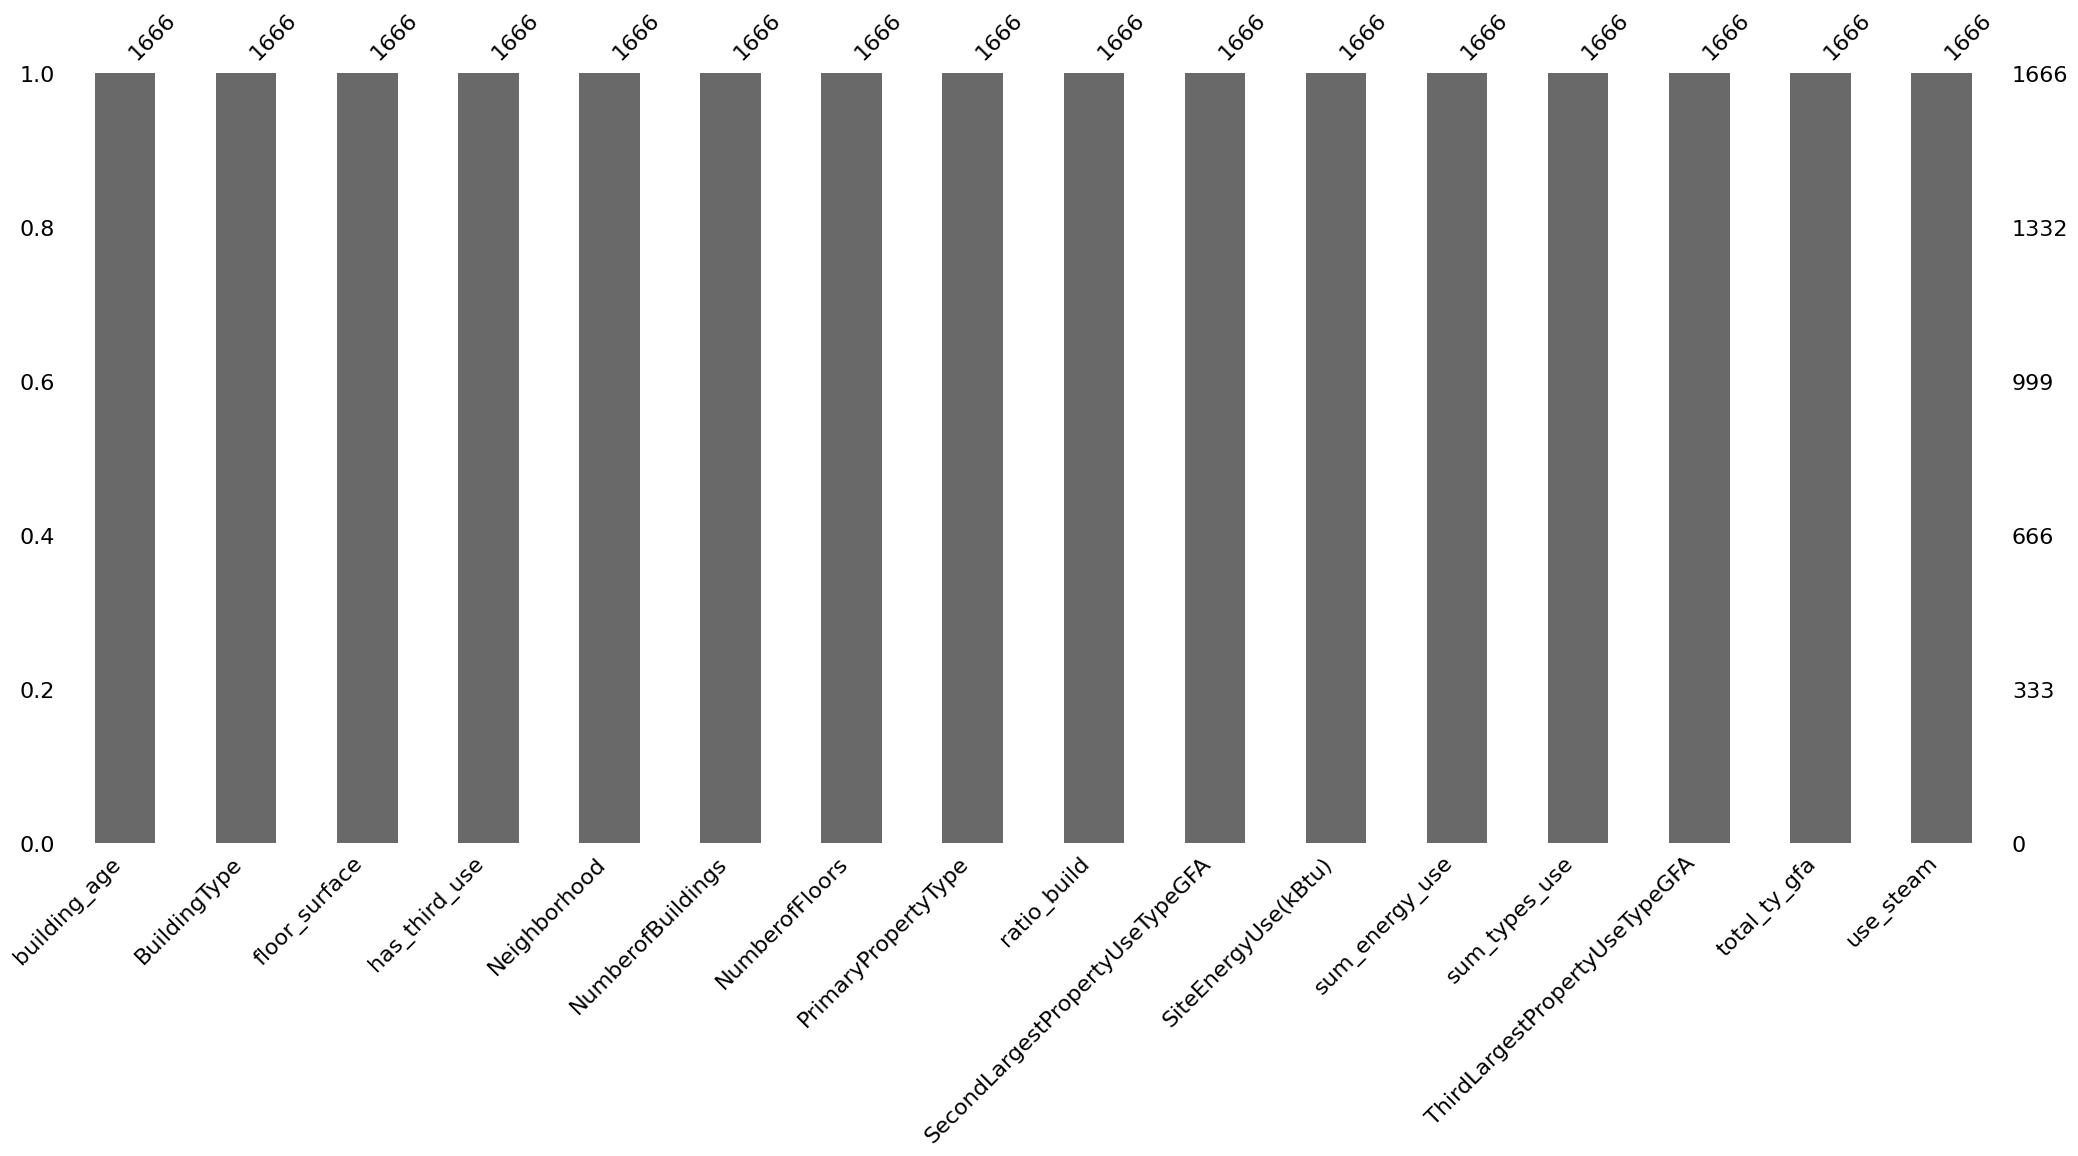

In [17]:
# supprime les entrées avec une target manquantes
df = df.dropna(subset = ['SiteEnergyUse(kBtu)'])

# on convertit les inf en nan
df = df.replace([np.inf, -np.inf],np.nan)

# on remplace tout les nan par veleurs numeriques = 0
df = df.fillna(0)

# visuel du résultat
msno.bar(df)
info(df, 'df sans inf et nan') 

#### Step 2 *outliers*
Il faut élaborer une approche pour les outliers qui sont nombreux mais naturels.

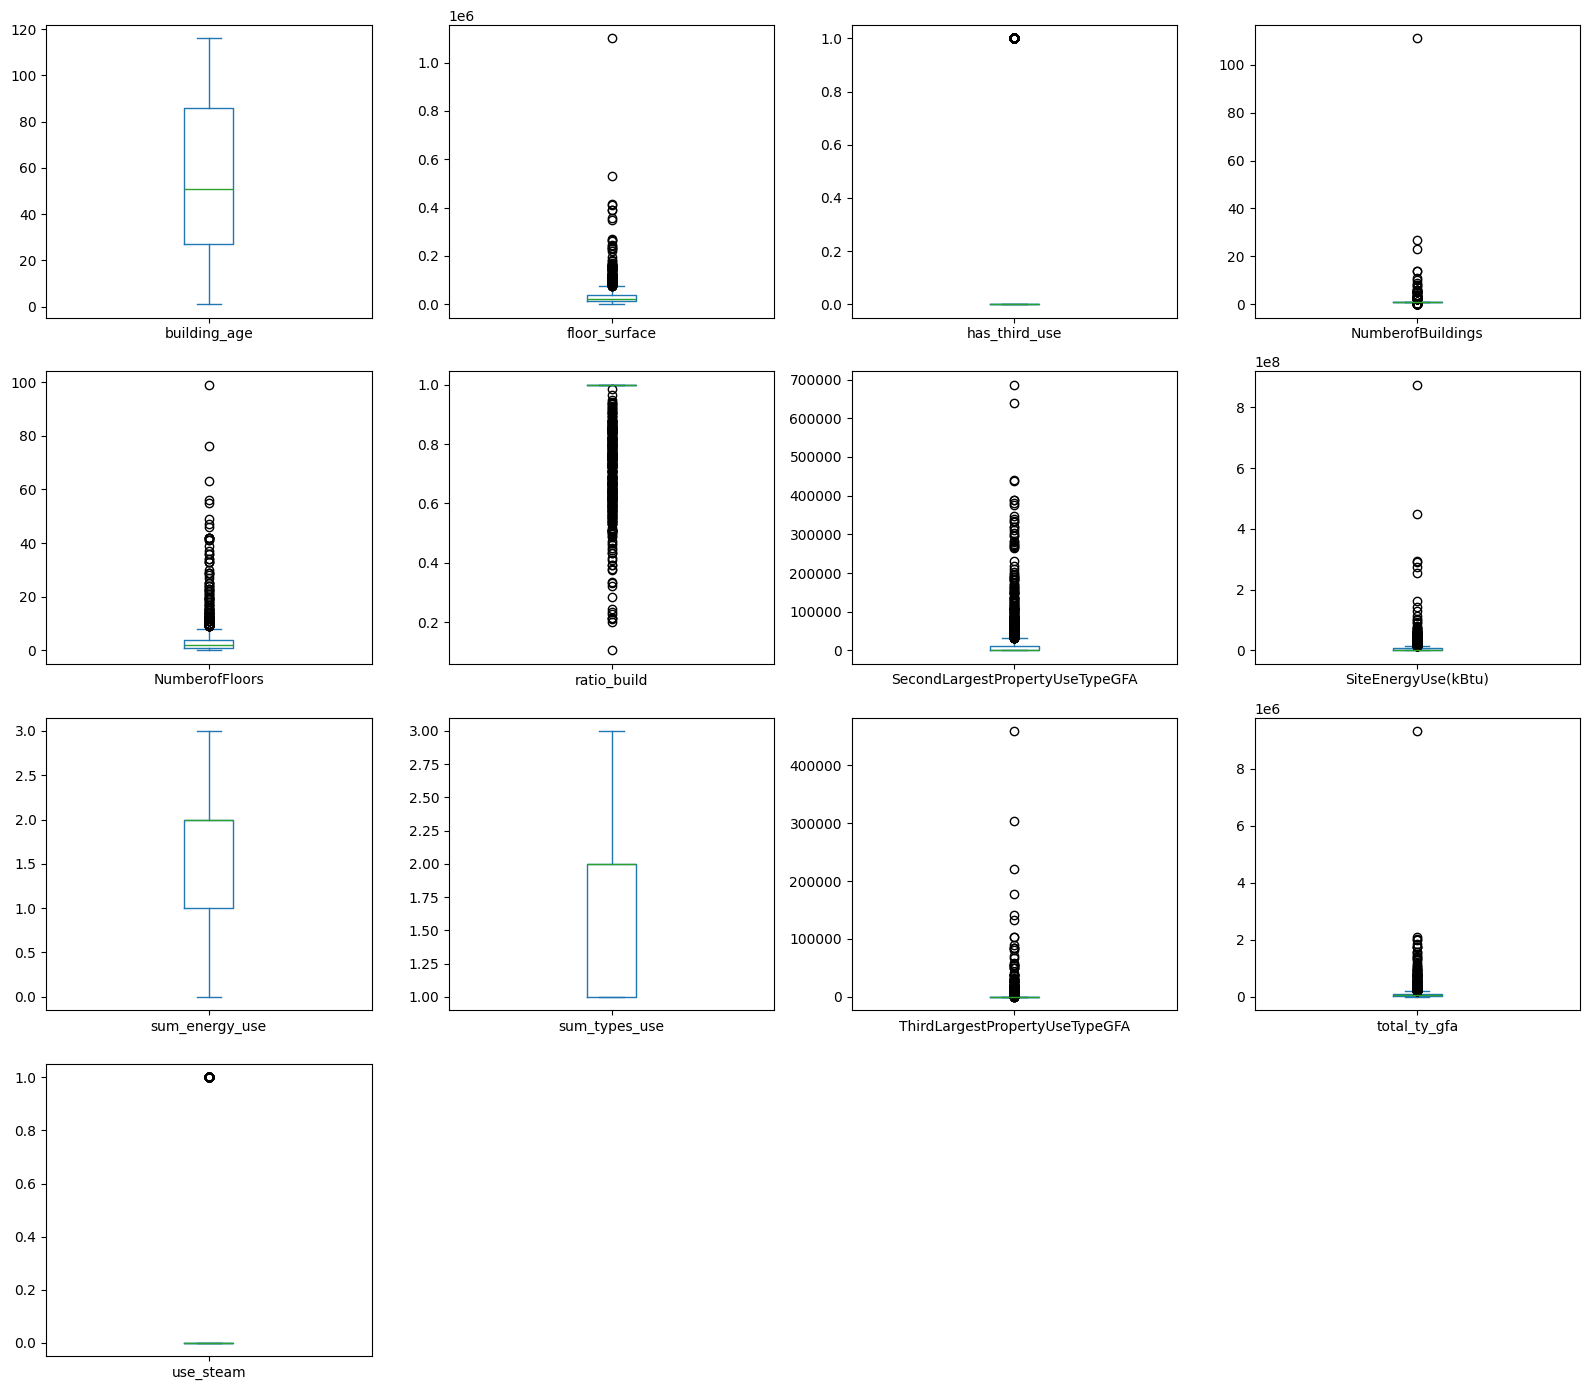

In [18]:
# boxplot pour les outlier juste pour identifier les colonnes sr le nouveau df
df.plot(kind = 'box', subplots = True, layout = (4, 4), figsize = (16, 14))
plt.tight_layout()
plt.show()

Comme les outliers sont utiles, ils seront garder et log-transformer, c'est à dire compressé les grandes valeurs et etirer les petites afin de rendre la feature plus symmétrique, et donc lisible pour le modèle (linéaire pour les modèles en arbre ca ne pose pas de problèmes) . 


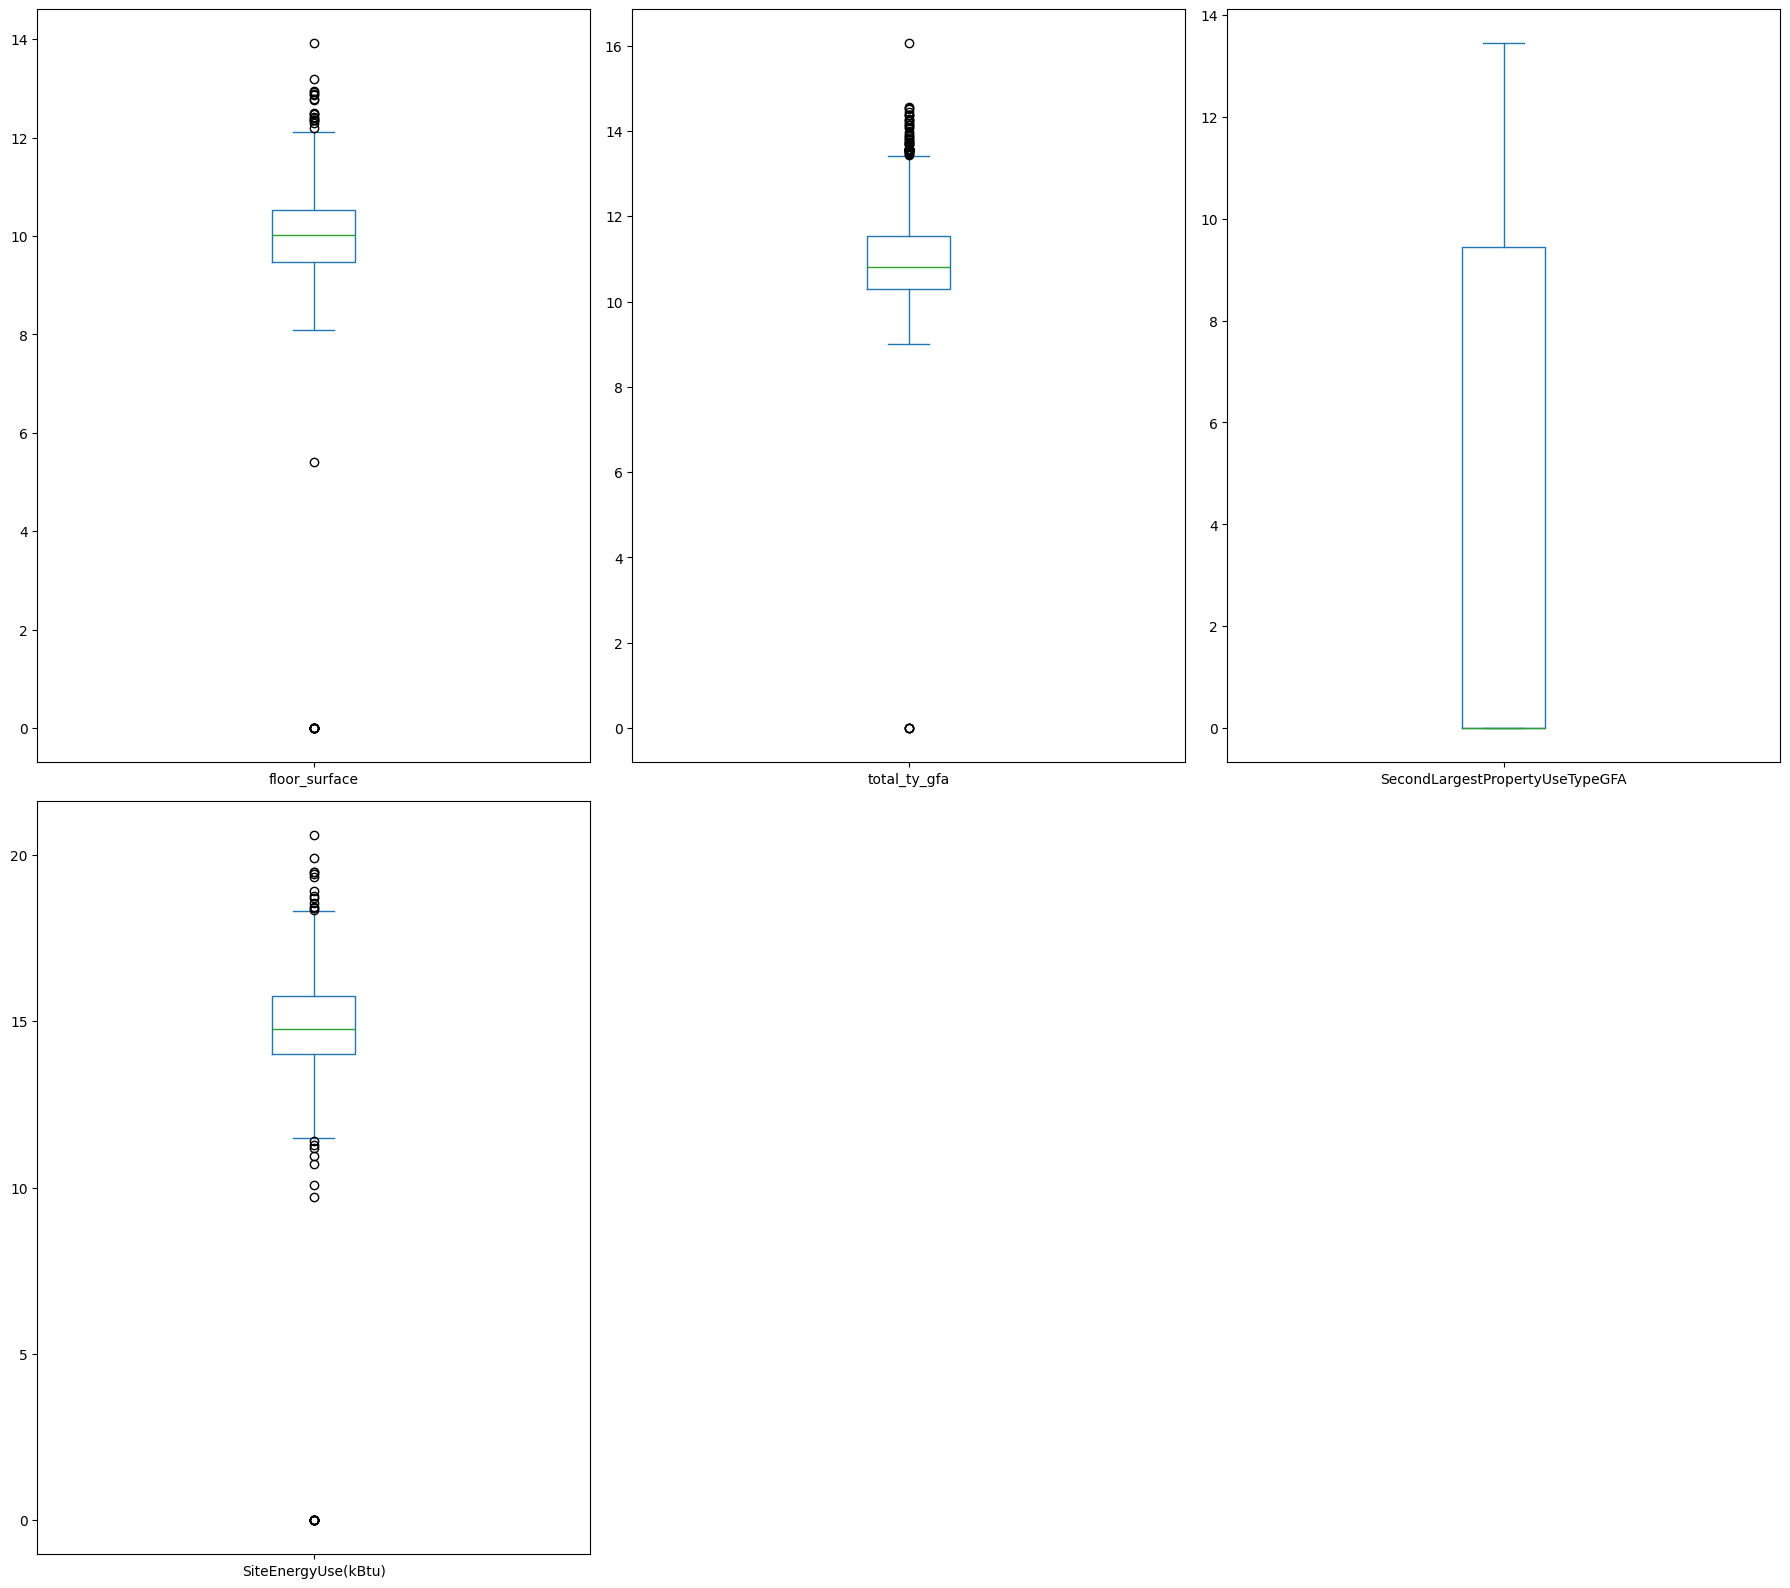

In [19]:
cols_on_log = [
    'floor_surface',
    'total_ty_gfa',
    'SecondLargestPropertyUseTypeGFA',
    'SiteEnergyUse(kBtu)',
]

cols_off_log = [
    'building_age',
    'NumberofBuildings',
    'NumberofFloors',
    'ratio_build',
    'use_steam',
    'has_third_use',
    'sum_energy_use',
    'sum_types_use',
    'ThirdLargestPropertyUseTypeGFA'
] 

df[cols_on_log] = np.log1p(df[cols_on_log])

# contrôle de nouveaux
df[cols_on_log].plot(kind = 'box', subplots = True, layout = (2, 3), figsize = (18, 16))
plt.tight_layout()
plt.show()

In [20]:
df.nlargest(5,'SiteEnergyUse(kBtu)')

,building_age,BuildingType,floor_surface,has_third_use,Neighborhood,NumberofBuildings,NumberofFloors,PrimaryPropertyType,ratio_build,SecondLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),sum_energy_use,sum_types_use,ThirdLargestPropertyUseTypeGFA,total_ty_gfa,use_steam
1627,116,Campus,0.000000,0,NORTHEAST,111.0,0,University,1.0,0.000000,20.588504,2,1,0.0,16.047690,1
34,24,Campus,12.013373,1,GREATER DUWAMISH,1.0,3,Mixed Use Property,1.0,13.369117,19.921163,2,3,459748.0,14.434315,0
168,16,NonResidential,11.883367,0,EAST,9.0,8,Hospital,1.0,12.867863,19.495993,3,2,0.0,14.368150,1
608,22,NonResidential,11.745161,0,EAST,7.0,14,Hospital,1.0,12.998051,19.490943,3,2,0.0,14.548304,1
548,35,NonResidential,9.473725,0,DOWNTOWN,1.0,33,Other,1.0,12.256813,19.431125,2,2,0.0,12.970160,0


In [21]:
df = df.drop(index = 1625)
df.info()

<class 'pandas.DataFrame'>
Index: 1665 entries, 0 to 1667
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   building_age                     1665 non-null   int64  
 1   BuildingType                     1665 non-null   str    
 2   floor_surface                    1665 non-null   float64
 3   has_third_use                    1665 non-null   int64  
 4   Neighborhood                     1665 non-null   str    
 5   NumberofBuildings                1665 non-null   float64
 6   NumberofFloors                   1665 non-null   int64  
 7   PrimaryPropertyType              1665 non-null   str    
 8   ratio_build                      1665 non-null   float64
 9   SecondLargestPropertyUseTypeGFA  1665 non-null   float64
 10  SiteEnergyUse(kBtu)              1665 non-null   float64
 11  sum_energy_use                   1665 non-null   int64  
 12  sum_types_use                    166

Malgré le log on retrouve des outliers;  

L'University of Washington compte en réalité plus de 500 bâtiments sur ses campus, alors que le dataset n'en déclare que 111, ( l'electicité consommée n'est structurelement pas bonne dans le dataset si il compte 111 bâtiment). La donnée est moinms aberante que la réalité du site — elle est à la fois structurellement incompatible avec le format une ligne = un bâtiment, et factuellement sous-estimée. Cette  entrée est retirée car non modélisable (index numéro 1625). Là il y a un problème de compliance.

Toutefois on constate que les données ont bien été normalisé mêmes parmi les outliers. Ce qui étirent les box ce sont surtout les 0 ce qui est normal quand il n'y a pas de données. 

#### Transformation : 
- colonnes en valeurs continue sont normalisées
- supression de l'index 1625 (Université de Washington)

#### Step 3 *train_test_split*
C'est la 1ère étape de la modélisation. Comme les modèle ML apprennent des fonction clasique et simple: y = f(X), il faut atribuer le y et le X. C'est ce que nous allons faire ici.


In [22]:
from sklearn.model_selection import train_test_split


In [23]:
# attribution des fonction X(toujours les features) et y(toujours la target)
y = df['SiteEnergyUse(kBtu)']
X = df.drop(columns = ['SiteEnergyUse(kBtu)'])

print(y.shape, X.shape)

(1665,) (1665, 15)


In [24]:
# On instancie le decoupage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2, # 20% des données sont conserver pour afin de tester
    random_state = 42 # Fige le split, mais le decoupage reste aleatoire (peu importe le chiffre mais il faut le conserver)
)

print(X_train.shape, X_test.shape)

(1332, 15) (333, 15)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [26]:
# pour les transformations de chaque colonnes, on instancie les types pour chaque méthodes

# colonnes categorielle pour OneHotEncoder
cat_cols = ['BuildingType', 'PrimaryPropertyType', 'Neighborhood']
# colonnes numeriques pour StandardScaler
bin_cols = ['use_steam', 'has_third_use']
# colonnes binaires pour passthrough
num_cols = [c for c in X.columns if c not in cat_cols + bin_cols]

print("num:", num_cols)
print("cat:", cat_cols)
print("bin:", bin_cols)


num: ['building_age', 'floor_surface', 'NumberofBuildings', 'NumberofFloors', 'ratio_build', 'SecondLargestPropertyUseTypeGFA', 'sum_energy_use', 'sum_types_use', 'ThirdLargestPropertyUseTypeGFA', 'total_ty_gfa']
cat: ['BuildingType', 'PrimaryPropertyType', 'Neighborhood']
bin: ['use_steam', 'has_third_use']


In [27]:
# pipeline de transformation pour chaque ensemble de colonne avec sa transformation

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output = False,handle_unknown  = 'ignore', max_categories = 10),cat_cols), 
        ('bin', 'passthrough', bin_cols),
    ]
)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
#pipeline complet 
lr_pipe = Pipeline(steps = [
    ('prep', preprocessor), 
    ('model', LinearRegression())
])

lr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [30]:
# cross validate pour les minitest
from sklearn.model_selection import cross_validate

In [31]:
scoring = ['r2', 'neg_mean_absolute_error']

cv_lr = cross_validate(
    lr_pipe, X_train, y_train, 
    cv = 5, 
    scoring = scoring, 
)

print('R2 moyen :', cv_lr['test_r2'].mean().round(3))
print('MAE moyen:', (-cv_lr['test_neg_mean_absolute_error'].mean()).round(3))

R2 moyen : 0.375
MAE moyen: 0.882


Le R2 moyen est mauvais mais attendu pour une regression lineaire sur ces variables qui ne sont pas forcement linéaires.  
Les prochain modèles tenteront de dépasser cette baseline.

Les modeles choisis à tester; 
- LinearRegression : droite simple (déjà fait, baseline).
  - R2 moyen : 0.375
  - MAE moyen: 0.882  
- Ridge : régression linéaire « bridée » (régularisée) — évite que des coefficients explosent. Souvent un peu mieux que LinearRegression.
- RandomForest : moyenne de plein d'arbres de décision. Capte les relations non-linéaires et les interactions. Très robuste.
- GradientBoosting : des arbres construits en série, chacun corrigeant les erreurs du précédent. Souvent le plus performant.


In [33]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor